In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/melting-point/sample_submission.csv
/kaggle/input/melting-point/train.csv
/kaggle/input/melting-point/test.csv


In [2]:
!pip install rdkit
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 46.3 MB/s eta 0:00:00


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,KFold, cross_val_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor

In [4]:
data_train = pd.read_csv('../input/melting-point/train.csv')
data_test = pd.read_csv('../input/melting-point/test.csv')

print(data_train.shape)
print(data_test.shape)

(2662, 427)
(666, 426)


<Axes: xlabel='Tm', ylabel='Density'>

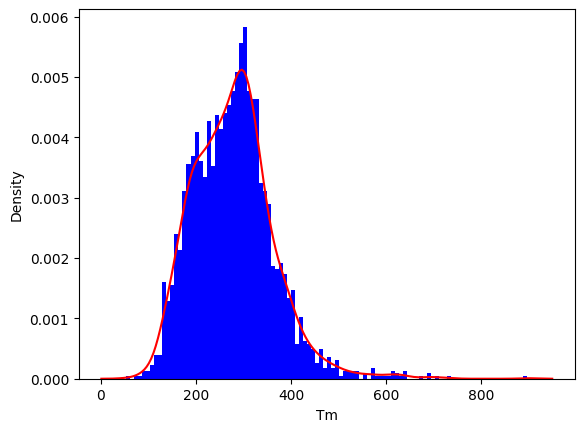

In [5]:
plt.hist(data_train['Tm'],bins=100,density=True,color='blue');
sns.kdeplot(data_train['Tm'], color='red')

In [6]:
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # Returning a Series with all None values if SMILES is invalid
        cols = ['BalabanJ', 'BertzCT', 'MolWt','NumRings',
                'NumHBA', 'NumHBD', 'NumHeteroatoms', 'SASA',
                'Chi0v', 'Chi3v', 'Kappa1', 'Kappa2']
        return pd.Series([None] * len(cols), index=cols)

    mol_wt = Descriptors.MolWt(mol)
    #tpsa = Descriptors.TPSA(mol)
    sasa = rdMolDescriptors.CalcLabuteASA(mol)
    num_rings = rdMolDescriptors.CalcNumRings(mol)
    num_hba = rdMolDescriptors.CalcNumHBA(mol)
    num_hbd = rdMolDescriptors.CalcNumHBD(mol)
    num_heteroatoms = Descriptors.NumHeteroatoms(mol)
    balaban_j = Descriptors.BalabanJ(mol) if mol.GetNumAtoms() > 1 else 0
    bertz_ct = Descriptors.BertzCT(mol)
    chi0v = rdMolDescriptors.CalcChi0v(mol)
    chi3v = rdMolDescriptors.CalcChi3v(mol)
    kappa1 = rdMolDescriptors.CalcKappa1(mol)
    kappa2 = rdMolDescriptors.CalcKappa2(mol)

    return pd.Series([
        balaban_j, bertz_ct, mol_wt,num_rings,
        num_hba, num_hbd, num_heteroatoms, sasa,
        chi0v, chi3v, kappa1, kappa2
    ], index=[
        'BalabanJ', 'BertzCT', 'MolWt', 'NumRings',
        'NumHBA', 'NumHBD', 'NumHeteroatoms','SASA',
        'Chi0v', 'Chi3v', 'Kappa1', 'Kappa2'
    ])

# Apply the function to the 'SMILES' column of each DataFrame
X_train_descriptors = data_train['SMILES'].apply(calculate_descriptors)
X_test_descriptors = data_test['SMILES'].apply(calculate_descriptors) # Using X_test as defined previously (data_test[['id', 'SMILES']])


# Drop specified columns from the respective DataFrames before concatenation (if they exist).
data_train = data_train.drop(columns=['mol', 'BalabanJ','BertzCT', 'MolWt'], errors='ignore')
data_test = data_test.drop(columns=['mol', 'BalabanJ','BertzCT', 'MolWt'], errors='ignore')

# Concatenate the new descriptors with the original DataFrames
data_train = pd.concat([data_train, X_train_descriptors], axis=1)
data_test = pd.concat([data_test, X_test_descriptors], axis=1)

print("Molecular descriptors calculated and added to data_train:")
print("\nMolecular descriptors calculated and added to data_test:")

Molecular descriptors calculated and added to data_train:

Molecular descriptors calculated and added to data_test:


In [7]:
df_train=data_train.drop(columns=['id','SMILES','Tm'])
df_test=data_test.drop(columns=['id','SMILES'])
y_train=data_train['Tm']

In [8]:
# 1. Initialize StandardScaler and CatBoostRegressor with specified parameters
scaler = StandardScaler()
cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0, # Suppress training output
    loss_function='MAE',
    eval_metric='MAE',
    task_type='CPU', # Ensure CPU for broader compatibility
    iterations=10000,
    depth=6,
    learning_rate=0.02,
    l2_leaf_reg=3,
    border_count=64,
    bagging_temperature=1,
    subsample=0.8,
    min_data_in_leaf=10,
    colsample_bylevel=0.8,
    grow_policy='SymmetricTree'
)

# 2. Create a Pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('catboost', cat_model)
])

# 3. Fit the pipeline to the entire training dataset
pipeline.fit(df_train, y_train,catboost__early_stopping_rounds=100)
print("Training complete.")

Training complete.


In [9]:
# 4. Use the trained pipeline to make predictions on the preprocessed test data
test_predictions = pipeline.predict(df_test)

# 5. Create a Pandas DataFrame for submission
submission_df = pd.DataFrame({'id': data_test['id'], 'Tm': test_predictions})
submission_df.to_csv("submission.csv", index=False)

In [10]:
submission_df.head(5)

,id,Tm
0,1022,342.168287
1,1146,324.126312
2,79,211.183778
3,2279,206.910834
4,1342,230.094165
